# Iona PBDEs Concentration and Discharge

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import datetime as dt
import xarray as xr
from scipy.optimize import least_squares
from scipy import stats
import os

# Load Roger's updated data

In [2]:
path = 'C:/Users/vicen/OneDrive - UBC/MASTER_UBC/RESEARCH/PBDEs data/Updated_PBDEs_data_Roger.xlsx'

In [3]:
sheet_conc_dis = pd.read_excel(path, sheet_name='conc. and dis.')
sheet_consumption = pd.read_excel(path, sheet_name='consumption')

In [4]:
names_BDE = ['BDE-17+25', 'BDE-28+33', 'BDE-47', 'BDE-49', 'BDE-66', 'BDE-85', 'BDE-99', 'BDE-100', 'BDE-138', 
             'BDE-140', 'BDE-153', 'BDE-154', 'BDE-155', 'BDE-183', 'BDE-203', 'BDE-206', 'BDE-207', 'BDE-208', 'BDE-209']
concentration_string = ' Iona effluent conc. (pg/L)            '
discharge_string = ' Iona discharge rate (kg/y)            '
consumption_string = ' consump rate (kg/y) '

In [5]:
discharge_obs = pd.DataFrame(columns=names_BDE, index=sheet_conc_dis['sampling date'].values)
consumption_obs = pd.DataFrame(columns=names_BDE, index=pd.to_datetime(sheet_consumption['time(1 Jan; y)'].values, format='%Y'))
consumption_obs_daily = consumption_obs.resample('1D').asfreq()

In [6]:
for names in names_BDE:
    discharge_obs[names] = sheet_conc_dis[names+discharge_string].values
    consumption_obs[names] = sheet_consumption[names+consumption_string].values


In [7]:
for congener in names_BDE:
    consumption_daily = pd.to_numeric(consumption_obs[congener], errors='coerce').resample("1D").interpolate("linear")
    consumption_obs_daily[congener] = consumption_daily

In [8]:
time_discharge = discharge_obs.index.to_pydatetime().tolist()
time_consumption = consumption_obs_daily.index.to_pydatetime().tolist()

In [9]:
dt=1/365

In [ ]:
def discharge_function(alpha, beta, congener_index):
    
    pool = np.zeros(len(consumption_obs_daily))# in Kilograms
    dis = np.zeros(len(consumption_obs_daily)) # in grams per day
    #
    # Data_daily is in Kilograms per year
    for i in range(len(pool)):
        pool[i]=pool[i-1]+dt*(consumption_obs_daily[congener_index].values[i-1]-(alpha + beta)*pool[i-1])
        #pool[i]=pool[i-1]+dt*(consumption_obs_daily[congener_index].values[i-1]-(beta)*pool[i-1])        
        dis[i]=alpha*(pool[i]) * (1000/365) # fINAL DISCHARGE IN GRAMS PER DAY
    #
    return dis 
# This function gives me a dataframe as an output

In [ ]:
def residuals(predicted, congener_index):
    res=np.zeros(len(discharge_obs[congener_index]))
    #
    for i in range(len(predicted)):
        for j in range(len(discharge_obs[congener_index])):
            if np.isnan(discharge_obs[congener_index].values[j])==False:
                if time_consumption[i]==time_discharge[j]:
                    res[j]=discharge_obs[congener_index].values[j]-predicted[i]
    return res
# This function gives me the difference between the daily observed discharge vs the daily predicted discharge

In [12]:
def optimize(params, congener):
    alpha=params[0]
    beta=params[1]
    predicted=discharge_function(alpha, beta, congener)
    res=residuals(predicted, congener)
    return res

---

In [468]:
alpha, beta = 0.00005, 0.15 # per year

In [469]:
alpha_and_beta = pd.DataFrame(index = ['alpha', 'beta'], columns=names_BDE)
alpha_and_beta_std = pd.DataFrame(index = ['alpha_std', 'beta_std', 'alpha_95_CI', 'beta_95_CI', 'alpha_significant_flag', 'beta_significant_flag'], columns=names_BDE)

#
PBDEs_discharge_predicted = pd.DataFrame(columns=names_BDE)

In [ ]:
confidence_level = 0.95
significance_threshold = 0.05

for congener in names_BDE:
    def optimization(parameters):
        return optimize(parameters, congener)

    LS = least_squares(optimization, [alpha, beta], method='trf')
    
    alpha_and_beta.loc['alpha', congener] = LS.x[0]   
    alpha_and_beta.loc['beta', congener] = LS.x[1]

    n = len(LS.fun)
    p = len(LS.x)
    dof = n - p
    
    alpha_sig_flag = 0
    beta_sig_flag = 0
    p_values = np.array([np.nan, np.nan])
    
    if dof > 0:
        try:
            sigma2 = np.sum(LS.fun**2) / dof
            J = LS.jac
            cov_matrix = sigma2 * np.linalg.inv(J.T @ J)
            parameter_errors = np.sqrt(np.diag(cov_matrix)) 
            
            t_crit = stats.t.ppf((1 + confidence_level) / 2, dof)
            ci_margins = t_crit * parameter_errors


            t_stats = LS.x / (parameter_errors + 1e-10) 
            

            p_values = 2 * stats.t.sf(np.abs(t_stats), dof)


            if p_values[0] < significance_threshold:
                alpha_sig_flag = 1
            else:
                print(f"{congener}: Alpha not significant (p={p_values[0]:.3f})")

            if p_values[1] < significance_threshold:
                beta_sig_flag = 1
            else:
                print(f" {congener}: Beta not significant (p={p_values[1]:.3f})")

        except np.linalg.LinAlgError:
            print(f"{congener}: Matrix calculation failed.")
    else:
        print(f"{congener}: Not enough data.")


    alpha_and_beta_std.loc['alpha_std', congener] = parameter_errors[0]   
    alpha_and_beta_std.loc['beta_std', congener] = parameter_errors[1]
    
    alpha_and_beta_std.loc['alpha_95_CI', congener] = ci_margins[0]
    alpha_and_beta_std.loc['beta_95_CI', congener] = ci_margins[1]

    alpha_and_beta_std.loc['alpha_p_value', congener] = p_values[0]
    alpha_and_beta_std.loc['beta_p_value', congener] = p_values[1]
    
    alpha_and_beta_std.loc['alpha_significant_flag', congener] = alpha_sig_flag
    alpha_and_beta_std.loc['beta_significant_flag', congener] = beta_sig_flag

    prediction = discharge_function(LS.x[0], LS.x[1], congener)
    PBDEs_discharge_predicted[congener] = pd.Series(prediction, index=time_consumption)
#
#alpha_and_beta.to_csv('alpha_and_beta_values_UPDATED.csv', index=True)
#alpha_and_beta_std.to_csv('alpha_and_beta_std_values_UPDATED.csv', index=True)
#PBDEs_discharge_predicted.to_csv('PBDEs_discharge_predictions_UPDATED.csv', index=True)   
alpha_and_beta.to_csv('alpha_and_beta_values_UPDATED_V2.csv', index=True)
alpha_and_beta_std.to_csv('alpha_and_beta_std_values_UPDATED_V2.csv', index=True)
PBDEs_discharge_predicted.to_csv('PBDEs_discharge_predictions_UPDATED_V2.csv', index=True) 

# LOAD AND VISUALIZE

In [14]:
alpha_beta = pd.read_csv('alpha_and_beta_values_UPDATED.csv').drop(columns='Unnamed: 0')
alpha_beta_stats = pd.read_csv('alpha_and_beta_std_values_UPDATED.csv').drop(columns='Unnamed: 0')
discharge = pd.read_csv('PBDEs_discharge_predictions_UPDATED.csv').drop(columns='Unnamed: 0')

In [15]:
alpha_beta_V2 = pd.read_csv('alpha_and_beta_values_UPDATED_V2.csv').drop(columns='Unnamed: 0')
alpha_beta_stats_V2 = pd.read_csv('alpha_and_beta_std_values_UPDATED_V2.csv').drop(columns='Unnamed: 0')
discharge_V2 = pd.read_csv('PBDEs_discharge_predictions_UPDATED_V2.csv').drop(columns='Unnamed: 0')


----

Table with new $\alpha$ and $\beta$ for Roger

In [16]:
alphaV2 = alpha_beta_V2.iloc[0]
betaV2 = alpha_beta_V2.iloc[1]
#
alphaV2_95CI = alpha_beta_stats_V2.iloc[2]
betaV2_95CI = alpha_beta_stats_V2.iloc[3]

In [17]:
ALPHA_BETA_V2 = pd.DataFrame([alphaV2, betaV2, alphaV2_95CI, betaV2_95CI], index = ['alpha', 'beta', 'alpha_95CI', 'beta_95CI'])

In [18]:
ALPHA_BETA_V2.to_excel('Updated_alpha_and_beta_Table_Roger.xlsx', index = True)

----

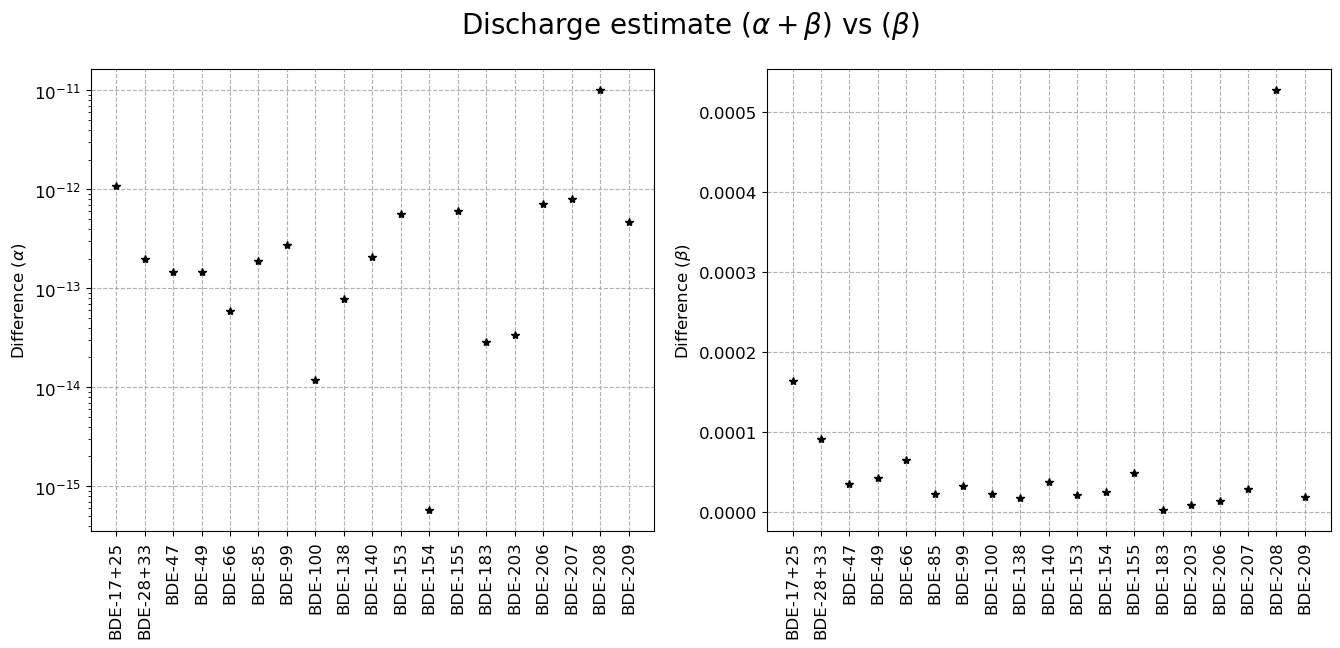

In [19]:
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(1,2,figsize = (16,6))
ax[0].plot(np.abs(alpha_beta.iloc[0] - alpha_beta_V2.iloc[0]), '*k')
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'Difference ($\alpha$)')
ax[1].plot(np.abs(alpha_beta.iloc[1] - alpha_beta_V2.iloc[1]), '*k')
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_ylabel(r'Difference ($\beta$)')

plt.suptitle(r'Discharge estimate ($\alpha + \beta$) vs ($\beta$)', fontsize = 20)
ax[0].grid(linestyle = '--'); ax[1].grid(linestyle = '--')

In [20]:
#alpha_beta = alpha_beta.drop(columns=names_BDE[-2])
#alpha_beta_stats = alpha_beta_stats.drop(columns=names_BDE[-2])
#discharge = discharge.drop(columns=names_BDE[-2])

In [21]:
alpha = alpha_beta.iloc[0]
beta = alpha_beta.iloc[1]

In [22]:
alpha_std = alpha_beta_stats.iloc[0]
beta_std = alpha_beta_stats.iloc[1]
alpha_95CI = alpha_beta_stats.iloc[2]
beta_95CI = alpha_beta_stats.iloc[3]
alpha_p_value = alpha_beta_stats.iloc[6]
beta_p_value = alpha_beta_stats.iloc[7]


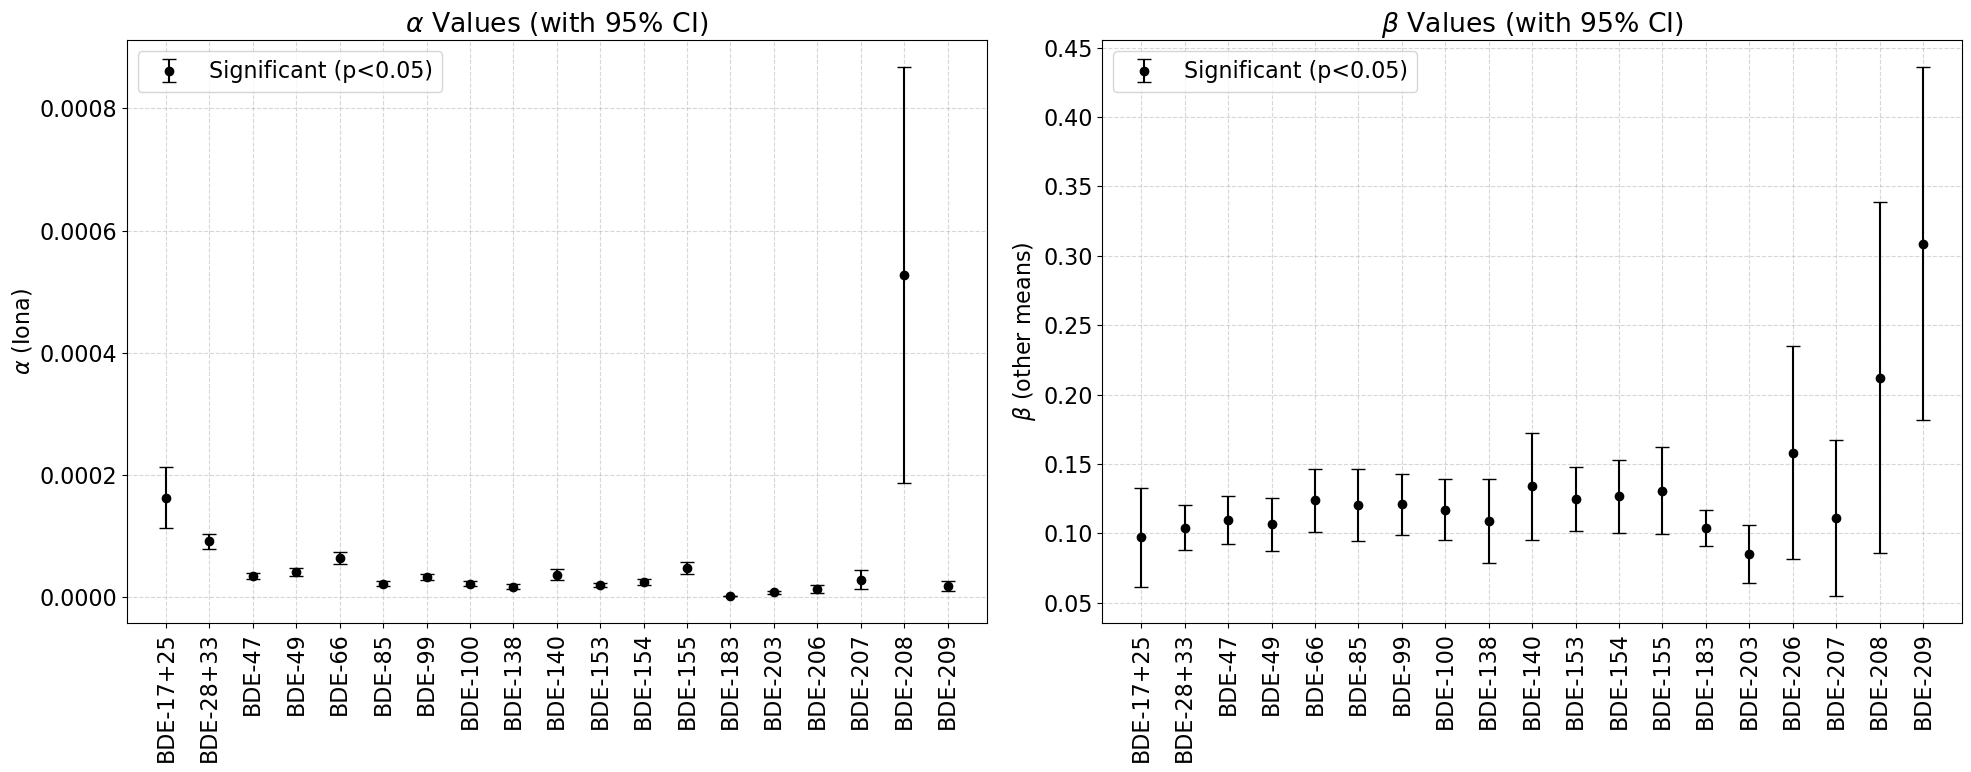

In [23]:
alpha_arr = np.array(alpha)
beta_arr = np.array(beta)
names = names_BDE#[:-2] + [names_BDE[-1]]
names_arr = np.array(names)

alpha_ci_arr = np.array(alpha_95CI, dtype=float)
beta_ci_arr = np.array(beta_95CI, dtype=float)
alpha_p_arr = np.array(alpha_p_value, dtype=float)
beta_p_arr = np.array(beta_p_value, dtype=float)

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

def plot_with_significance(ax_idx, x_data, y_data, y_err, p_values, title, ylabel):
    # 1. Create Masks for Significant vs Not Significant (p < 0.05)
    sig_mask = p_values < 0.05
    not_sig_mask = ~sig_mask

    # 2. Plot Significant Points (Black, Solid)
    ax_idx.errorbar(x_data[sig_mask], y_data[sig_mask], 
                    yerr=y_err[sig_mask], 
                    fmt='o', color='black', ecolor='black', 
                    capsize=5, label='Significant (p<0.05)')


    # Formatting
    ax_idx.set_title(title)
    ax_idx.set_ylabel(ylabel)
    ax_idx.tick_params(axis='x', rotation=90)
    ax_idx.grid(linestyle='--', alpha=0.5)
    ax_idx.legend()


# --- PLOT ALPHA ---
plot_with_significance(ax[0], names_arr, alpha_arr, alpha_ci_arr, alpha_p_arr, 
                       r'$\alpha$ Values (with 95% CI)', r'$\alpha$ (Iona)')

# --- PLOT BETA ---
plot_with_significance(ax[1], names_arr, beta_arr, beta_ci_arr, beta_p_arr, 
                       r'$\beta$ Values (with 95% CI)', r'$\beta$ (other means)')

plt.tight_layout()
plt.show()


# Alpha

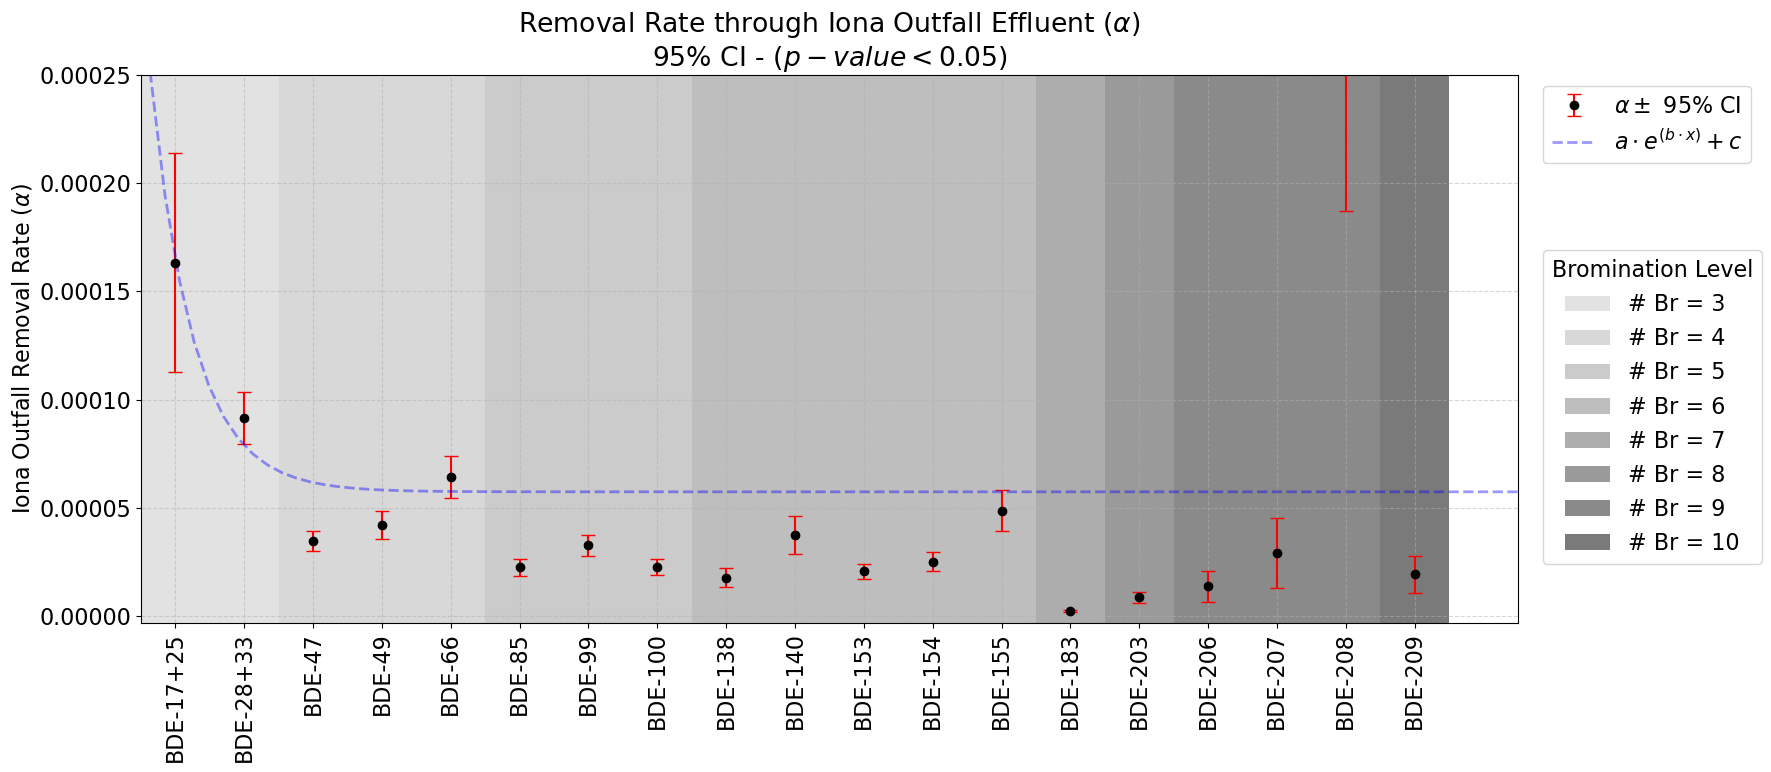

In [24]:
from scipy.optimize import curve_fit

alpha_arr = np.array(alpha)
names = names_BDE#[:-2] + [names_BDE[-1]]
names_arr = np.array(names)
alpha_ci_arr = np.array(alpha_95CI, dtype=float)
alpha_p_arr = np.array(alpha_p_value, dtype=float)

def adjustment(x, a, b, c):
    return a * np.exp(b * x) + c

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(18, 8))

sig_mask = alpha_p_arr < 0.05

data_handle = ax.errorbar(names_arr[sig_mask], alpha_arr[sig_mask], yerr=alpha_ci_arr[sig_mask], 
                          fmt='o', color='black', ecolor='r', capsize=5, label=r'$\alpha \pm$ 95% CI')

ax.set_title(r'Removal Rate through Iona Outfall Effluent ($\alpha$)' + '\n' + r'95% CI - ($p-value < 0.05$)')
ax.set_ylabel(r'Iona Outfall Removal Rate ($\alpha$)')
ax.tick_params(axis='x', rotation=90)
ax.grid(linestyle='--', alpha=0.5)

x_numeric = np.arange(len(names_arr)) 
x_smooth = np.linspace(-1, len(names_arr)+1, 100)

guess_alpha = [max(alpha_arr), -0.5, 0]
popt_a, _ = curve_fit(adjustment, x_numeric, alpha_arr, p0=guess_alpha, maxfev=5000)

y_smooth_a = adjustment(x_smooth, *popt_a)


fit_line_handle = ax.plot(x_smooth, y_smooth_a, 'b--', linewidth=2, alpha=0.4, label=r'$a \cdot e^{(b \cdot x)} + c$')[0]


first_legend = ax.legend(handles=[data_handle, fit_line_handle], bbox_to_anchor=(1.01, 1))

ax.add_artist(first_legend)

regions = [
    (-0.5, 1.5, '# Br = 3'),
    (1.5, 4.5, '# Br = 4'),
    (4.5, 7.5, '# Br = 5'),
    (7.5, 12.5, '# Br = 6'),
    (12.5, 13.5, '# Br = 7'),
    (13.5, 14.5, '# Br = 8'),
    (14.5, 17.5, '# Br = 9'),
    (17.5, 18.5, '# Br = 10')
]

cmap = plt.get_cmap('Greys') 
colors = [cmap(i) for i in np.linspace(0.2, 0.6, len(regions))]

region_handles = [] 

for i, (start, end, label_text) in enumerate(regions):
    h = ax.fill_between(
        [start, end],     
        -.000003, 0.0003,         
        color=colors[i],  
        alpha=1,        
        zorder=0,         
        edgecolor='none',  
        label=label_text  
    )
    region_handles.append(h)

ax.legend(handles=region_handles, title="Bromination Level", 
          loc='upper left', bbox_to_anchor=(1.01, .7))

ax.set_xlim(-.5, 19.5); ax.set_ylim(-.000003, 0.00025)


plt.tight_layout()
plt.show()

In [25]:
# for the poster

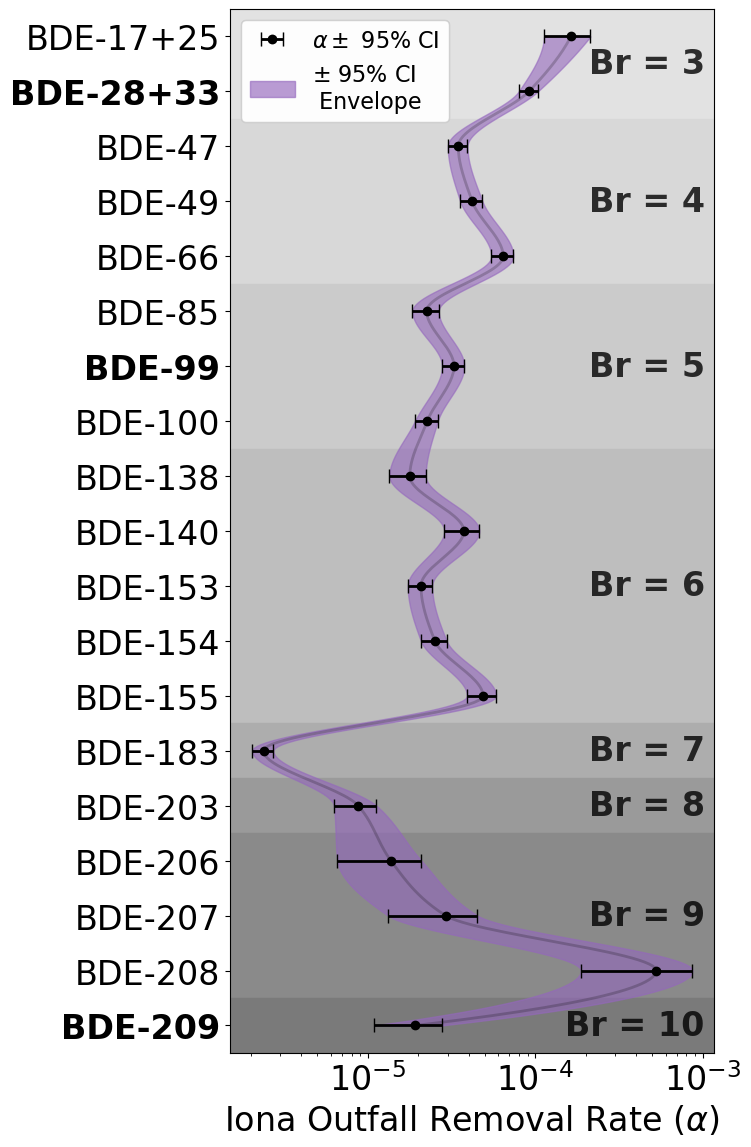

In [ ]:

from scipy.interpolate import PchipInterpolator

alpha_arr = np.array(alpha).astype(float)
alpha_ci_arr = np.array(alpha_95CI).astype(float)
alpha_p_arr = np.array(alpha_p_value).astype(float)
names_arr = np.array(names_BDE)

plt.rcParams.update({'font.size': 24})

fig, ax = plt.subplots(figsize=(8, 12))

sig_mask = alpha_p_arr < 0.05
x_vals = alpha_arr[sig_mask]
names_filtered = names_arr[sig_mask]
x_errs = alpha_ci_arr[sig_mask]

y_indices = np.arange(len(names_filtered))

y_smooth = np.linspace(y_indices.min(), y_indices.max(), 500)

lower_vals_raw = x_vals - x_errs
upper_vals_raw = x_vals + x_errs

lower_vals_safe = np.maximum(lower_vals_raw, 1e-10)
upper_vals_safe = np.maximum(upper_vals_raw, 1e-10)
x_vals_safe = np.maximum(x_vals, 1e-10)

pchip_main = PchipInterpolator(y_indices, np.log(x_vals_safe))
x_smooth = np.exp(pchip_main(y_smooth)) 

pchip_lower = PchipInterpolator(y_indices, np.log(lower_vals_safe))
x_lower_smooth = np.exp(pchip_lower(y_smooth))

pchip_upper = PchipInterpolator(y_indices, np.log(upper_vals_safe))
x_upper_smooth = np.exp(pchip_upper(y_smooth))

errors_handle = ax.fill_betweenx(y_smooth, x_lower_smooth, x_upper_smooth, 
                                 color='tab:purple', alpha=0.6, label=r'$\pm$ 95% CI'+'\n Envelope')

ax.plot(x_smooth, y_smooth, color='k', alpha=0.2, linewidth=2, label='Interpolated Trend')

data_handle = ax.errorbar(x_vals, y_indices, 
            xerr=x_errs, 
            fmt='o', color='black', ecolor='k', capsize=5, linewidth=2, 
            label=r'$\alpha \pm$ 95% CI', zorder=3)

ax.set_yticks(y_indices)
ax.set_yticklabels(names_filtered)
ax.set_xlabel(r'Iona Outfall Removal Rate ($\alpha$)') 
ax.invert_yaxis() 
plt.xscale('log')

target_bold = ['BDE-28+33', 'BDE-99', 'BDE-209']

for label in ax.get_yticklabels():
    if label.get_text() in target_bold:
        label.set_fontweight('bold')

handles_list = [data_handle, errors_handle]
first_legend = ax.legend(handles=handles_list, loc='upper left', fontsize = 16)
ax.add_artist(first_legend)

regions = [
    (-0.5, 1.5, 'Br = 3'),
    (1.5, 4.5, 'Br = 4'),
    (4.5, 7.5, 'Br = 5'),
    (7.5, 12.5, 'Br = 6'),
    (12.5, 13.5, 'Br = 7'),
    (13.5, 14.5, 'Br = 8'),
    (14.5, 17.5, 'Br = 9'),
    (17.5, 18.5, 'Br = 10')
]

cmap = plt.get_cmap('Greys') 
colors = [cmap(i) for i in np.linspace(0.2, 0.6, len(regions))]

for i, (start, end, label_text) in enumerate(regions):
    ax.axhspan(start, end, 
               color=colors[i], 
               alpha=1, 
               zorder=0)
    
    y_center = (start + end) / 2
    ax.text(0.98, y_center, label_text, 
            transform=ax.get_yaxis_transform(), 
            ha='right', va='center',            
            fontweight='bold', color='black', alpha=0.8)

ax.set_ylim(18.5, -0.5)
plt.tight_layout()
plt.show()

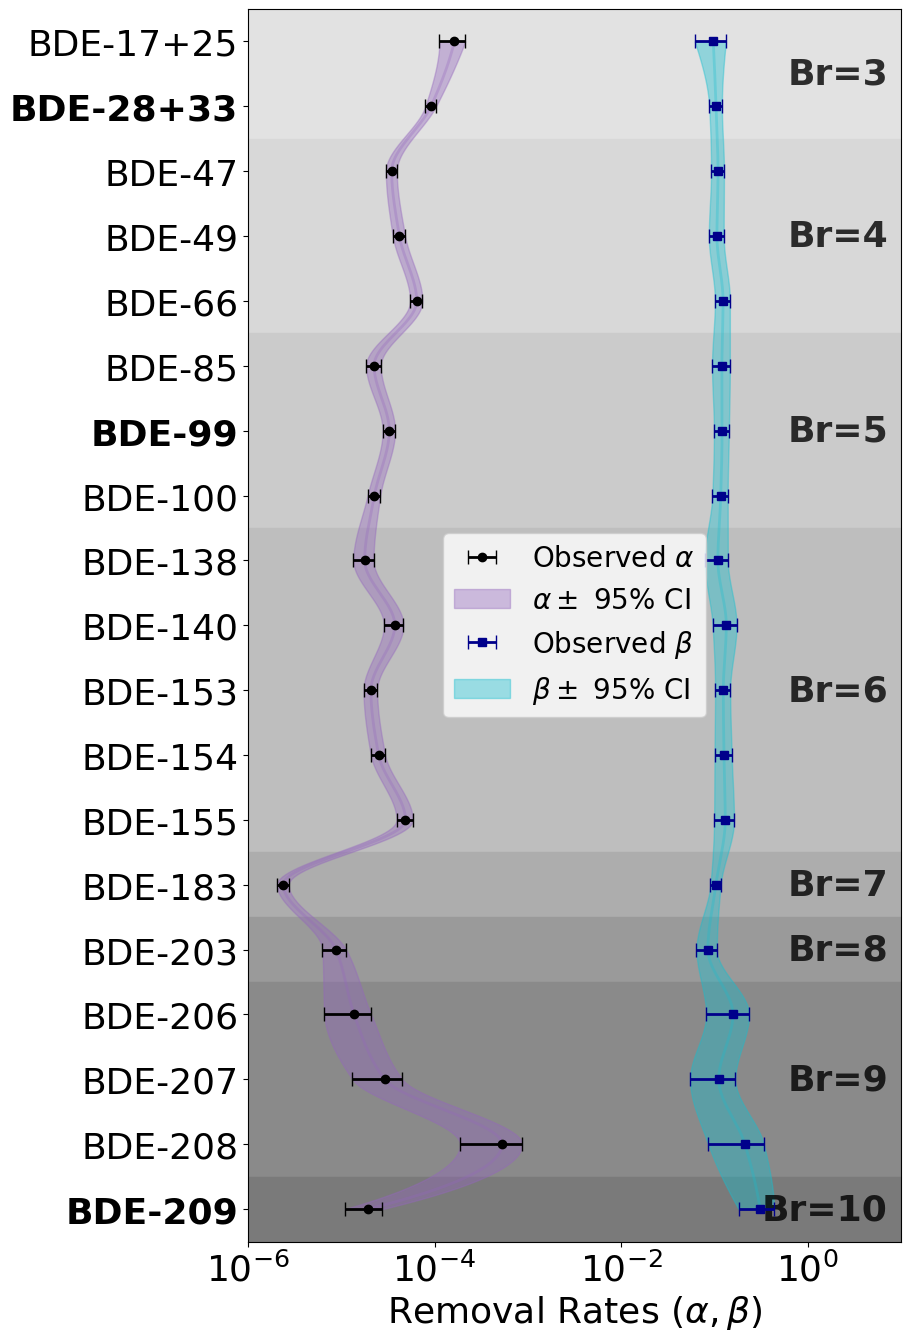

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator

# Load your data arrays
alpha_arr = np.array(alpha).astype(float)
alpha_ci_arr = np.array(alpha_95CI).astype(float)
alpha_p_arr = np.array(alpha_p_value).astype(float)
names_arr = np.array(names_BDE)

# New Beta arrays
beta_arr = np.array(beta).astype(float)
beta_ci_arr = np.array(beta_95CI).astype(float)
beta_p_arr = np.array(beta_p_value).astype(float)

plt.rcParams.update({'font.size': 26})
fig, ax = plt.subplots(figsize=(10, 14))

# Filter based on alpha significance (as per original logic)
sig_mask = alpha_p_arr < 0.05
names_filtered = names_arr[sig_mask]
y_indices = np.arange(len(names_filtered))
y_smooth = np.linspace(y_indices.min(), y_indices.max(), 500)

# Helper function to generate Pchip interpolations for values and CIs
def get_smooth_curves(vals_subset, errs_subset):
    lower_vals_safe = np.maximum(vals_subset - errs_subset, 1e-10)
    upper_vals_safe = np.maximum(vals_subset + errs_subset, 1e-10)
    vals_safe = np.maximum(vals_subset, 1e-10)

    pchip_main = PchipInterpolator(y_indices, np.log(vals_safe))
    pchip_low = PchipInterpolator(y_indices, np.log(lower_vals_safe))
    pchip_up = PchipInterpolator(y_indices, np.log(upper_vals_safe))
    
    return (np.exp(pchip_main(y_smooth)), 
            np.exp(pchip_low(y_smooth)), 
            np.exp(pchip_up(y_smooth)))

# Generate smooth curves for Alpha
a_mid, a_low, a_high = get_smooth_curves(alpha_arr[sig_mask], alpha_ci_arr[sig_mask])

# Generate smooth curves for Beta
b_mid, b_low, b_high = get_smooth_curves(beta_arr[sig_mask], beta_ci_arr[sig_mask])

# --- Plot Alpha ---
err_alpha_h = ax.fill_betweenx(y_smooth, a_low, a_high, color='tab:purple', alpha=0.4, 
                               label=r'$\alpha \pm$ 95% CI')
ax.plot(a_mid, y_smooth, color='tab:purple', alpha=0.3, linewidth=2)
data_alpha_h = ax.errorbar(alpha_arr[sig_mask], y_indices, xerr=alpha_ci_arr[sig_mask], 
                            fmt='o', color='black', ecolor='black', capsize=5, 
                            linewidth=2, label=r'Observed $\alpha$', zorder=4)

# --- Plot Beta ---
err_beta_h = ax.fill_betweenx(y_smooth, b_low, b_high, color='tab:cyan', alpha=0.4, 
                              label=r'$\beta \pm$ 95% CI')
ax.plot(b_mid, y_smooth, color='tab:cyan', alpha=0.3, linewidth=2)
data_beta_h = ax.errorbar(beta_arr[sig_mask], y_indices, xerr=beta_ci_arr[sig_mask], 
                           fmt='s', color='darkblue', ecolor='darkblue', capsize=5, 
                           linewidth=2, label=r'Observed $\beta$', zorder=5)

# Formatting
ax.set_yticks(y_indices)
ax.set_yticklabels(names_filtered)
ax.set_xlabel(r'Removal Rates ($\alpha, \beta$)') 
ax.invert_yaxis() 
plt.xscale('log')

# Bold specific target names
target_bold = ['BDE-28+33', 'BDE-99', 'BDE-209']
for label in ax.get_yticklabels():
    if label.get_text() in target_bold:
        label.set_fontweight('bold')

# Legend
handles = [data_alpha_h, err_alpha_h, data_beta_h, err_beta_h]
ax.legend(handles=handles, loc='center', fontsize=20, framealpha=0.8)

# Background Regions
regions = [(-0.5, 1.5, 'Br=3'), (1.5, 4.5, 'Br=4'), (4.5, 7.5, 'Br=5'), 
           (7.5, 12.5, 'Br=6'), (12.5, 13.5, 'Br=7'), (13.5, 14.5, 'Br=8'), 
           (14.5, 17.5, 'Br=9'), (17.5, 18.5, 'Br=10')]

cmap = plt.get_cmap('Greys') 
colors = [cmap(i) for i in np.linspace(0.2, 0.6, len(regions))]

for i, (start, end, label_text) in enumerate(regions):
    ax.axhspan(start, end, 
               color=colors[i], 
               alpha=1, 
               zorder=0)
    
    y_center = (start + end) / 2
    ax.text(0.98, y_center, label_text, 
            transform=ax.get_yaxis_transform(), 
            ha='right', va='center',            
            fontweight='bold', color='black', alpha=0.8)

ax.set_ylim(len(names_filtered)-0.5, -0.5)
ax.set_xlim(1e-6, 10)
plt.tight_layout()
plt.show()

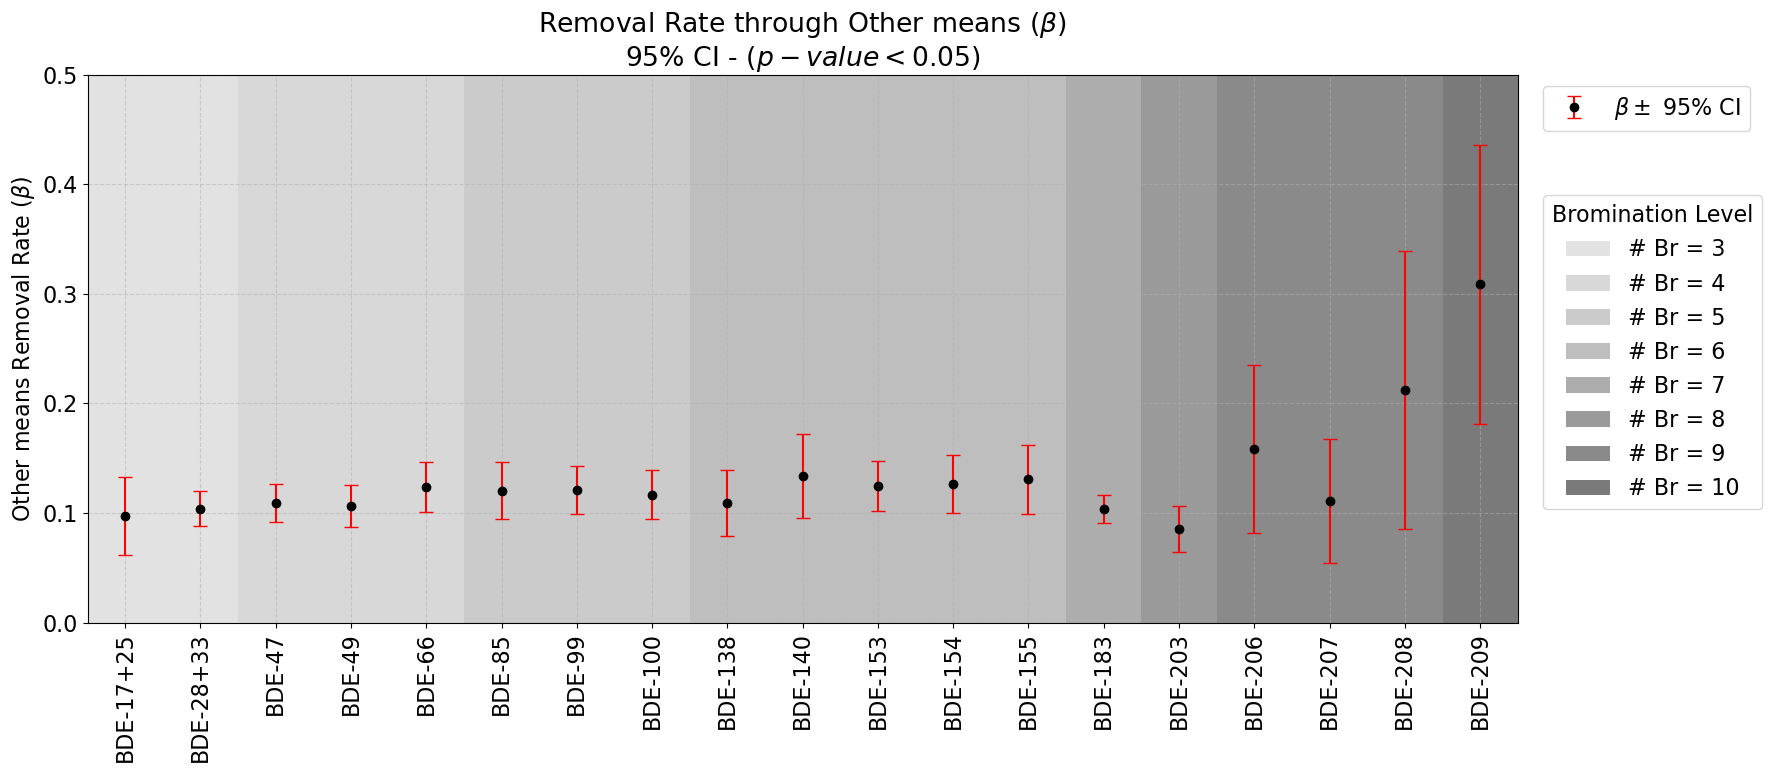

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

beta_arr = np.array(beta)
names = names_BDE
names_arr = np.array(names)
beta_ci_arr = np.array(beta_95CI, dtype=float)
beta_p_arr = np.array(beta_p_value, dtype=float)



plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(18, 8))

sig_mask = beta_p_arr < 0.05

data_handle = ax.errorbar(names_arr[sig_mask], beta_arr[sig_mask], yerr=beta_ci_arr[sig_mask], 
                          fmt='o', color='black', ecolor='r', capsize=5, label=r'$\beta \pm$ 95% CI')

ax.set_title(r'Removal Rate through Other means ($\beta$)' + '\n' + r'95% CI - ($p-value < 0.05$)')
ax.set_ylabel(r'Other means Removal Rate ($\beta$)')
ax.tick_params(axis='x', rotation=90)
ax.grid(linestyle='--', alpha=0.5)


handles_list = [data_handle]


first_legend = ax.legend(handles=handles_list, bbox_to_anchor=(1.01, 1))
ax.add_artist(first_legend)

regions = [
    (-0.5, 1.5, '# Br = 3'),
    (1.5, 4.5, '# Br = 4'),
    (4.5, 7.5, '# Br = 5'),
    (7.5, 12.5, '# Br = 6'),
    (12.5, 13.5, '# Br = 7'),
    (13.5, 14.5, '# Br = 8'),
    (14.5, 17.5, '# Br = 9'),
    (17.5, 18.5, '# Br = 10')
]

cmap = plt.get_cmap('Greys') 
colors = [cmap(i) for i in np.linspace(0.2, 0.6, len(regions))]

region_handles = [] 


y_shade_max = 0.5 

for i, (start, end, label_text) in enumerate(regions):
    h = ax.fill_between(
        [start, end],     
        0, y_shade_max,  
        color=colors[i],  
        alpha=1,        
        zorder=0,         
        edgecolor='none',  
        label=label_text  
    )
    region_handles.append(h)

ax.legend(handles=region_handles, title="Bromination Level", 
          loc='upper left', bbox_to_anchor=(1.01, 0.8))

ax.set_ylim(0, 0.5) 
ax.set_xlim(-0.5, 18.5)

plt.tight_layout()
plt.show()

# Discharge Time Series Fit

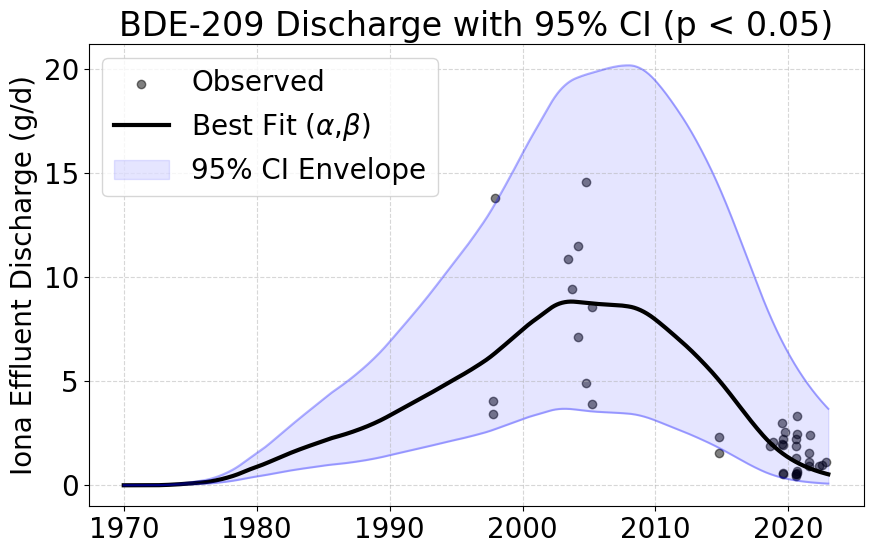

In [28]:
plt.rcParams.update({'font.size': 20})
idx = 18
congener_name = names[idx]
opt_alpha = alpha[congener_name]
opt_beta = beta[congener_name]
err_alpha = alpha_95CI[congener_name]
err_beta = beta_95CI[congener_name]

main_prediction = discharge_function(opt_alpha, opt_beta, congener_name)

bound_1 = discharge_function(opt_alpha - err_alpha, opt_beta + err_beta, congener_name)
#bound_2 = discharge_function(opt_alpha - err_alpha, opt_beta - err_beta, congener_name)
bound_3 = discharge_function(opt_alpha + err_alpha, opt_beta - err_beta, congener_name)
#bound_4 = discharge_function(opt_alpha + err_alpha, opt_beta + err_beta, congener_name)

plt.figure(figsize=(10, 6))
plt.title(rf"{congener_name} Discharge with 95% CI (p < 0.05)")
plt.ylabel('Iona Effluent Discharge (g/d)')
plt.scatter(time_discharge,discharge_obs[congener_name], c='k', alpha = .5, label = 'Observed')
plt.plot(time_consumption, main_prediction, 'k', linewidth=3, label=r'Best Fit ($\alpha$,$\beta$)')


plt.plot(time_consumption, bound_1,'-b', alpha=0.3)#, label=r'($\alpha$-$\epsilon_{\alpha}$,$\beta$+$\epsilon_{\beta}$)')
#plt.plot(time_consumption, bound_2,'--r', alpha=0.7, label=r'($\alpha$-$\epsilon_{\alpha}$,$\beta$-$\epsilon_{\beta}$)')
plt.plot(time_consumption, bound_3,'-b', alpha=0.3)#, label=r'($\alpha$+$\epsilon_{\alpha}$,$\beta$-$\epsilon_{\beta}$)')
#plt.plot(time_consumption, bound_4,'--c', alpha=0.7, label=r'($\alpha$+$\epsilon_{\alpha}$,$\beta$+$\epsilon_{\beta}$)')
plt.fill_between(time_consumption, bound_1, bound_3, 
                 color='b', alpha=0.1, 
                 label=r'95% CI Envelope')

plt.legend(loc = 'upper left')
plt.grid(True, linestyle='--', alpha=0.5)
#
path = os.path.join('C:/Users/vicen/OneDrive - UBC/MASTER_UBC/RESEARCH/FIGURES/Iona_Effluent')
file = os.path.join(path, congener_name + '_discharge.png')
plt.savefig(file)

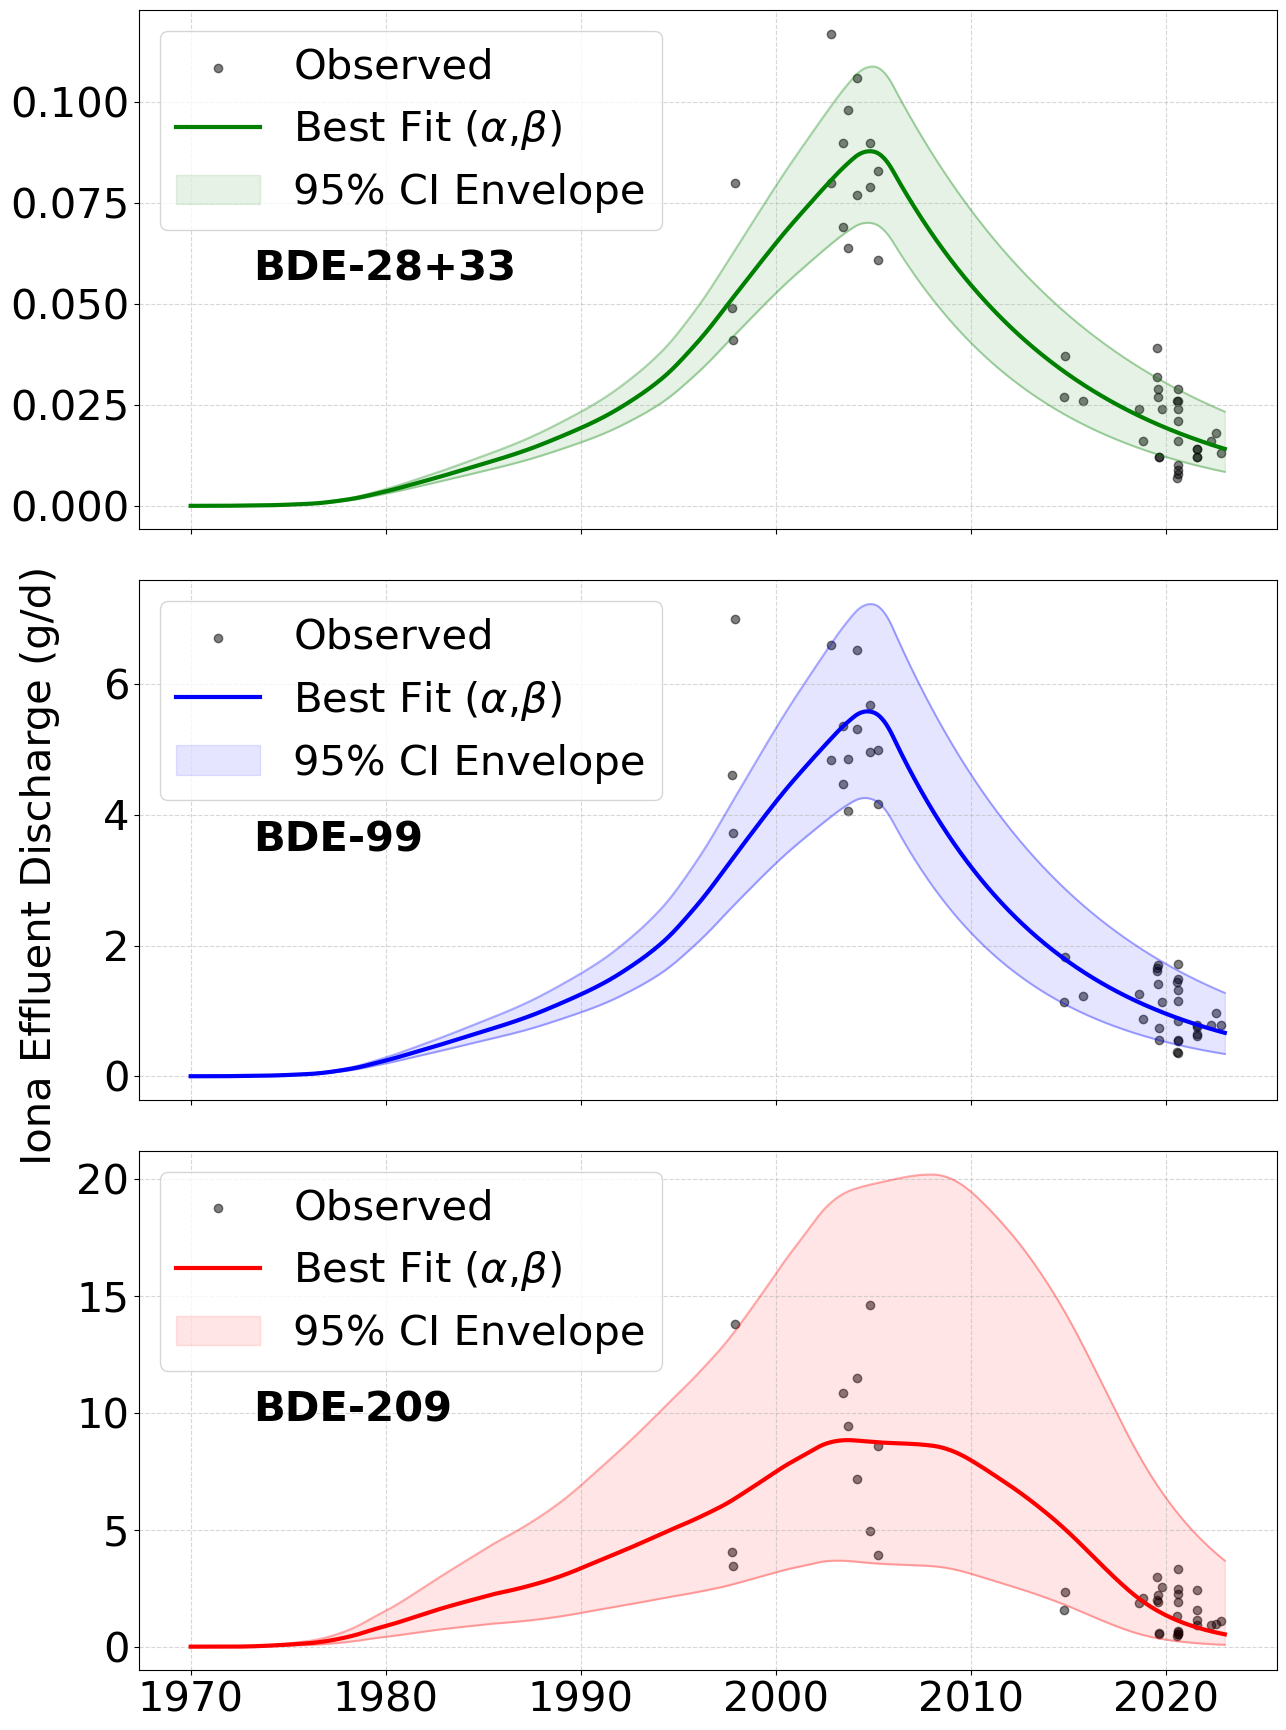

In [ ]:
plt.rcParams.update({'font.size': 30})

indices = [1, 6, 18]
colors = ['green', 'blue', 'red']

fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

for ax, idx, color in zip(axes, indices, colors):
    congener_name = names[idx]
    
    opt_alpha = alpha[congener_name]
    opt_beta = beta[congener_name]
    err_alpha = alpha_95CI[congener_name]
    err_beta = beta_95CI[congener_name]

    main_prediction = discharge_function(opt_alpha, opt_beta, congener_name)
    bound_1 = discharge_function(opt_alpha - err_alpha, opt_beta + err_beta, congener_name)
    bound_3 = discharge_function(opt_alpha + err_alpha, opt_beta - err_beta, congener_name)

    ax.text(0.1, 0.5, congener_name, 
            transform=ax.transAxes, 
            verticalalignment='center',
            fontweight='bold', fontsize=30)



    ax.scatter(time_discharge, discharge_obs[congener_name], c='k', alpha=0.5, label='Observed')
    
    ax.plot(time_consumption, main_prediction, color=color, linewidth=3, label=r'Best Fit ($\alpha$,$\beta$)')

    ax.plot(time_consumption, bound_1, color=color, linestyle='-', alpha=0.3)
    ax.plot(time_consumption, bound_3, color=color, linestyle='-', alpha=0.3)

    ax.fill_between(time_consumption, bound_1, bound_3, 
                    color=color, alpha=0.1, 
                    label=r'95% CI Envelope')

    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)


fig.text(0.02, 0.5, 'Iona Effluent Discharge (g/d)', 
         va='center', rotation=90, fontsize=30)

plt.tight_layout(rect=[0, 0, 0.95, 1]) 
plt.show()

# Bromination

In [30]:
plt.rcParams.update({'font.size': 20})

In [31]:
ratio_main_alpha = alpha / (alpha + beta)
ratio_main_beta = beta / (alpha + beta)
#
ratio_bound1_alpha = (alpha - alpha_95CI) / ((alpha - alpha_95CI) + (beta - beta_95CI))
ratio_bound2_alpha = (alpha - alpha_95CI) / ((alpha - alpha_95CI) + (beta + beta_95CI))
ratio_bound3_alpha = (alpha + alpha_95CI) / ((alpha + alpha_95CI) + (beta - beta_95CI))
ratio_bound4_alpha = (alpha + alpha_95CI) / ((alpha + alpha_95CI) + (beta + beta_95CI))

In [32]:
Br_atoms = [3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 6, 6, 6, 7, 8, 9, 9, 9, 10]

In [33]:
alpha_V1 = alpha_beta.iloc[0]
alpha_95CI_V1 = alpha_beta_stats.iloc[2]
#
alpha_V2 = alpha_beta_V2.iloc[0]
alpha_95CI_V2 = alpha_beta_stats_V2.iloc[2]

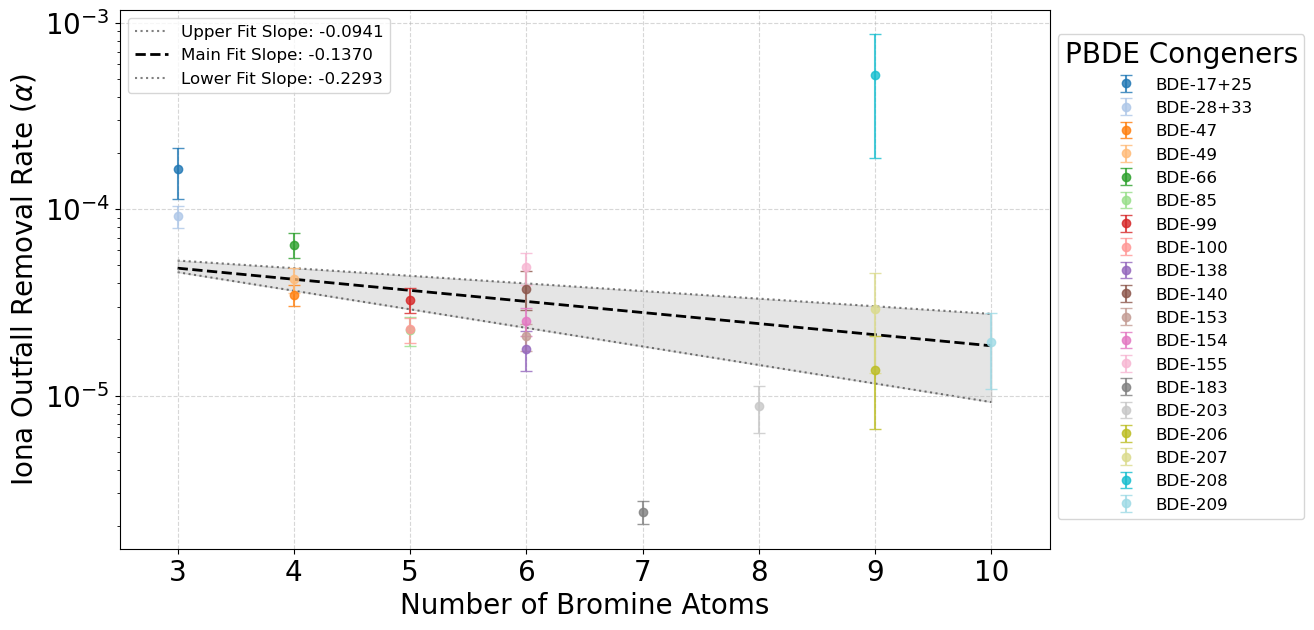

Main Slope:  -0.1370
Upper Slope: -0.0941
Lower Slope: -0.2293


In [ ]:

x_data = np.array(Br_atoms)
y_data = np.array(alpha_V1)
y_err  = np.array(alpha_95CI_V1)

y_upper = y_data + y_err
y_lower = y_data - y_err

def get_log_linear_fit(x_in, y_in):
    mask = y_in > 0
    if np.sum(mask) < 2: return None, None, None
        
    x_valid = x_in[mask]
    y_valid = y_in[mask]
    
    slope, intercept = np.polyfit(x_valid, np.log(y_valid), 1)
    
    a = np.exp(intercept)
    b = slope
    return a, b, (a, b)

# fits
a_main, b_main, _ = get_log_linear_fit(x_data, y_data)
a_up,   b_up,   _ = get_log_linear_fit(x_data, y_upper)
a_low,  b_low,  _ = get_log_linear_fit(x_data, y_lower)

# smooth lines for plotting
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit_main = a_main * np.exp(b_main * x_fit)
y_fit_up   = a_up   * np.exp(b_up   * x_fit)
y_fit_low  = a_low  * np.exp(b_low  * x_fit) if a_low is not None else np.zeros_like(x_fit)

cmap = plt.get_cmap('tab20') 
colores = [cmap(i) for i in np.linspace(0, 1, len(names_BDE))]

fig, ax = plt.subplots(figsize=(12, 7))

handles_PBDEs = []
# Plot 
for i, (x, y, yerr, color, label) in enumerate(zip(x_data, y_data, y_err, colores, names_BDE)):
    h = ax.errorbar(x, y, yerr=yerr, fmt='o', color=color, ecolor=color, 
                elinewidth=1.5, capsize=4, alpha=0.8, label=label)
    handles_PBDEs.append(h)



main = ax.plot(x_fit, y_fit_main, 'k--', linewidth=2, zorder=1, label='Main Fit Slope: -0.1370')
upper = ax.plot(x_fit, y_fit_up, 'gray', linestyle=':', linewidth=1.5, zorder=1, label='Upper Fit Slope: -0.0941')
lower = ax.plot(x_fit, y_fit_low, 'gray', linestyle=':', linewidth=1.5, zorder=1, label='Lower Fit Slope: -0.2293')
ax.fill_between(x_fit, y_fit_low, y_fit_up, color='k', alpha=0.1)
fits_handle = [upper[0], main[0], lower[0]]

ax.set_yscale('log')
ax.set_xlim(2.5, 10.5)
leyenda_fits = ax.legend(handles=fits_handle, fontsize = 12, loc = 'upper left')
ax.add_artist(leyenda_fits)
ax.legend(handles=handles_PBDEs, bbox_to_anchor=(1, 0.97), title = 'PBDE Congeners' ,fontsize=12)
ax.grid(linestyle = '--', alpha = .5)
ax.set_ylabel(r'Iona Outfall Removal Rate ($\alpha$)')
ax.set_xlabel(r'Number of Bromine Atoms')


plt.show()

print(f"Main Slope:  {b_main:.4f}")
print(f"Upper Slope: {b_up:.4f}")
print(f"Lower Slope: {b_low:.4f}")

In [35]:
beta_V1 = alpha_beta.iloc[1]
beta_95CI_V1 = alpha_beta_stats.iloc[3]
#
beta_V2 = alpha_beta_V2.iloc[1]
beta_95CI_V2 = alpha_beta_stats_V2.iloc[3]

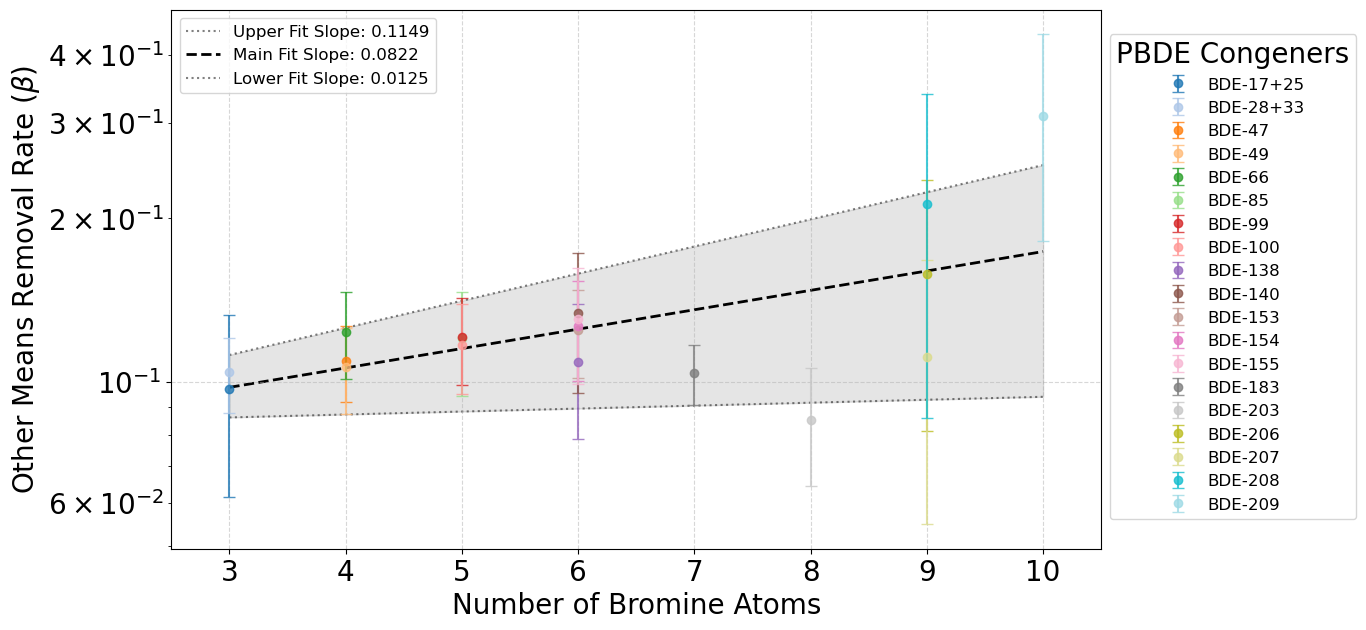

In [ ]:

x_data = np.array(Br_atoms)
y_data = np.array(beta_V1)
y_err  = np.array(beta_95CI_V1)

y_upper = y_data + y_err
y_lower = y_data - y_err

def get_log_linear_fit(x_in, y_in):
    mask = y_in > 0
    if np.sum(mask) < 2: return None, None, None
        
    x_valid = x_in[mask]
    y_valid = y_in[mask]
    
    # Fit: ln(y) = slope * x + intercept
    slope, intercept = np.polyfit(x_valid, np.log(y_valid), 1)
    
    # Convert back: y = a * exp(b * x)
    a = np.exp(intercept)
    b = slope
    return a, b, (a, b)

# fits
a_main, b_main, _ = get_log_linear_fit(x_data, y_data)
a_up,   b_up,   _ = get_log_linear_fit(x_data, y_upper)
a_low,  b_low,  _ = get_log_linear_fit(x_data, y_lower)

# smooth lines for plotting
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit_main = a_main * np.exp(b_main * x_fit)
y_fit_up   = a_up   * np.exp(b_up   * x_fit)
y_fit_low  = a_low  * np.exp(b_low  * x_fit) if a_low is not None else np.zeros_like(x_fit)

cmap = plt.get_cmap('tab20') 
colores = [cmap(i) for i in np.linspace(0, 1, len(names_BDE))]

fig, ax = plt.subplots(figsize=(12, 7))

handles_PBDEs = []
# Plot Data Points
for i, (x, y, yerr, color, label) in enumerate(zip(x_data, y_data, y_err, colores, names_BDE)):
    h = ax.errorbar(x, y, yerr=yerr, fmt='o', color=color, ecolor=color, 
                elinewidth=1.5, capsize=4, alpha=0.8, label=label)
    handles_PBDEs.append(h)



main = ax.plot(x_fit, y_fit_main, 'k--', linewidth=2, zorder=1, label=f'Main Fit Slope: {b_main:.4f}')
upper = ax.plot(x_fit, y_fit_up, 'gray', linestyle=':', linewidth=1.5, zorder=1, label=f'Upper Fit Slope: {b_up:.4f}')
lower = ax.plot(x_fit, y_fit_low, 'gray', linestyle=':', linewidth=1.5, zorder=1, label=f'Lower Fit Slope: {b_low:.4f}')
ax.fill_between(x_fit, y_fit_low, y_fit_up, color='k', alpha=0.1)
fits_handle = [upper[0], main[0], lower[0]]

ax.set_yscale('log')
ax.set_xlim(2.5, 10.5)
leyenda_fits = ax.legend(handles=fits_handle, fontsize = 12, loc = 'upper left')
ax.add_artist(leyenda_fits)
ax.legend(handles=handles_PBDEs, bbox_to_anchor=(1, 0.97), title = 'PBDE Congeners' ,fontsize=12)
ax.grid(linestyle = '--', alpha = .5)
ax.set_ylabel(r'Other Means Removal Rate ($\beta$)')
ax.set_xlabel(r'Number of Bromine Atoms')


plt.show()